Проектная работа. Группа 10. KNN. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

# Упражнения по методу KNN

Метод KNN для классификации достаточно простой, поэтому давайте применим наши знания для создания пайплайна и применения GridSearchCV - их можно будет использовать и для других моделей.

ФИО студента: 

Дата: 




## Набор данных профилей кандидатов HR Analytics

### О наборе данных

Набор данных aug_train.csv обеспечивает структурированное представление демографических, образовательных и профессиональных характеристик соискателей работы, что делает его очень актуальным для прогнозного моделирования в области человеческих ресурсов и карьерного анализа. Каждая строка соответствует отдельному кандидату, уникально идентифицируемому enrollee_id. Набор данных собирает географическую информацию с помощью переменной city и city_development_index, которые количественно определяют уровень социально-экономического развития региона, в котором находится кандидат. Это позволяет исследователям изучить, как городское развитие влияет на возможности трудоустройства.
Личные характеристики, такие как пол и соответствующий_опыт, подчеркивают разнообразие и предшествующее знакомство с рабочей силой. В наборе данных также указывается, обучаются ли кандидаты в настоящее время в университете (enrolled_university) и их самый высокий уровень образования, начиная от средней школы и заканчивая степенью магистра и магистра. Столбец major_discipline указывает область обучения, включая STEM, гуманитарные науки и другие дисциплины, что позволяет проводить сравнительный анализ академического образования. Эти особенности обеспечивают основу для изучения того, как образование и специализация влияют на карьерные траектории.
Помимо образования и демографии, набор данных включает переменные, связанные с историей трудоустройства, размером компании, последней сменой работы и другими факторами, связанными с карьерой. Вместе эти атрибуты делают набор данных подходящим для таких задач, как прогнозирование смены должностей, анализ карьерного пути и построение моделей машинного обучения для принятия решений в области управления персоналом. Его сбалансированное сочетание категориальных и числовых переменных поддерживает как статистический анализ, так и передовые методы моделирования.


Источник данных: https://www.kaggle.com/datasets/shraddha4ever20/candidate-profiles-for-employment-analysis


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('X_prepared_sample.csv')

In [3]:
df.head()

,city_development_index,experience,last_new_job,training_hours,target,no_job_info,is_university_enrolled,relevent_experience_No relevent experience,city_city_10,city_city_100,...,education_level_5,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_not_stated,gender_Male,gender_Other,gender_not_stated
0,0.920,21.0,1.0,36.0,1.0,1,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0.776,15.0,5.0,47.0,0.0,0,0,True,False,False,...,False,False,False,False,False,True,False,True,False,False
2,0.624,5.0,0.0,83.0,0.0,1,1,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,0.789,0.0,0.0,52.0,1.0,0,1,True,False,False,...,False,True,False,False,False,False,False,False,False,True
4,0.767,21.0,4.0,8.0,0.0,0,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Columns: 161 entries, city_development_index to gender_not_stated
dtypes: bool(154), float64(5), int64(2)
memory usage: 41.1 KB


In [5]:
df.describe()

,city_development_index,experience,last_new_job,training_hours,target,no_job_info,is_university_enrolled
count,200.000000,200.000000,200.000000,200.0000,200.000000,200.000000,200.000000
mean,0.829370,10.540000,2.050000,62.0975,0.230000,0.250000,0.245000
std,0.118938,6.985153,1.694656,51.7532,0.421889,0.434099,0.431166
min,0.550000,0.000000,0.000000,2.0000,0.000000,0.000000,0.000000
25%,0.760000,5.000000,1.000000,22.0000,0.000000,0.000000,0.000000
50%,0.896500,9.500000,1.000000,45.5000,0.000000,0.000000,0.000000
75%,0.920000,16.250000,3.000000,90.0000,0.000000,0.250000,0.000000
max,0.949000,21.000000,5.000000,185.5000,1.000000,1.000000,1.000000


## Исследование данных

**ЗАДАНИЕ: Нарисуйте тепловую карту heatmap, показывающую корреляцию между откликами на различных частотах.**

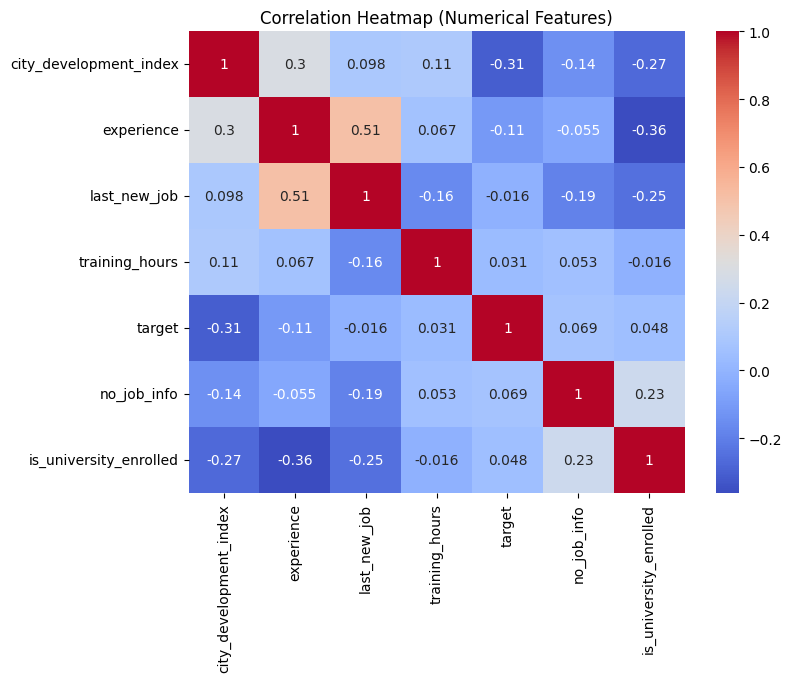

In [8]:
# Напишите Ваш код здесь
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

Тепловая карта показывает корреляцию между числовыми признаками в наборе данных. В целом большинство корреляций слабые, что означает отсутствие сильных линейных связей между переменными.
Самая сильная корреляция наблюдается между experience и city_development_index, указывая на то, что у людей с большим experience, как правило, прошло больше времени с момента последней смены работы. Кроме того, city_development_index имеет умеренную отрицательную корреляцию с целевым показателем, что говорит о том, что жители более развитых городов с меньшей вероятностью будут менять работу.

**Какие 5 признаков имеют наибольшую корреляцию с целевой переменной?**

*Замечание: Вы можете пометить целевую переменную с помощью значений 0 и 1.*

*Замечание 2: мы ищем **абсолютные** значения корреляции.*

In [9]:
# Напишите Ваш код здесь
target_corr = df.corr()['target'].abs().sort_values(ascending=False)

target_corr.head(6)

target                    1.000000
city_development_index    0.305343
city_city_21              0.260459
city_city_101             0.183892
city_city_115             0.183892
city_city_19              0.129704
Name: target, dtype: float64

Наиболее коррелированные функции включают в себя несколько городских переменных с горячим кодированием, таких как city_city_21 и city_city_101, что позволяет предположить, что некоторые города могут быть связаны с поведением при смене работы.Однако, поскольку эти функции являются двоичными, а набор данных небольшой, эти корреляции могут быть ненадежными.
Среди них city_development_index имеет более стабильную и значимую связь с целью.

Freq_45    0.339406
Freq_10    0.341142
Freq_49    0.351312
Freq_12    0.392245
Freq_11    0.432855
Target     1.000000
Name: Target, dtype: float64

## Разбиение на обучающий и тестовый наборы данных

Здесь мы будем использовать кросс-валидацию на 90% данных, и затем оценим результаты работы нашей модели на тестовом наборе данных в 10%.

**ЗАДАНИЕ: Разделите данные на признаки и целевую переменную, а затем разбейте все данные на обучающий и тестовый наборы данных, в отношении 90% и 10%.**

In [10]:
# Напишите Ваш код здесь
X = df.drop('target', axis=1)
y = df['target']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

Набор данных разделен на обучающий и тестовый наборы в соотношении 90–10%. Стратификация применяется для сохранения распределения классов целевой переменной. Это гарантирует, что оба набора представляют данные более надежно.

**ЗАДАНИЕ: Создайте объект PipeLine, в котором будет StandardScaler и модель KNN**

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

**ЗАДАНИЕ: С помощью пайплайна выполните поиск по сетке для различных значений k, и выведите наилучшие параметры.**

In [15]:
from sklearn.model_selection import GridSearchCV

In [16]:
param_grid = {
    'knn__n_neighbors': list(range(1, 30))
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [17]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

In [18]:
print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Best parameters: {'knn__n_neighbors': 6}
Best score: 0.788888888888889


Результаты поиска по сетке показывают, что наилучшее значение k — 6. Это значение обеспечивает самую высокую точность перекрестной проверки — примерно 0,79.
Это указывает на то, что умеренное количество соседей дает лучшую производительность, балансируя между переобучением и недостаточностью.

ЗАДАНИЕ: Используя словарь .cv_results_, попробуйте нарисовать график средних тестовых оценок (mean_test_score) для каждого значения K.**

In [19]:
# Напишите Ваш код здесь
k_values = grid.cv_results_['param_knn__n_neighbors']
mean_scores = grid.cv_results_['mean_test_score']

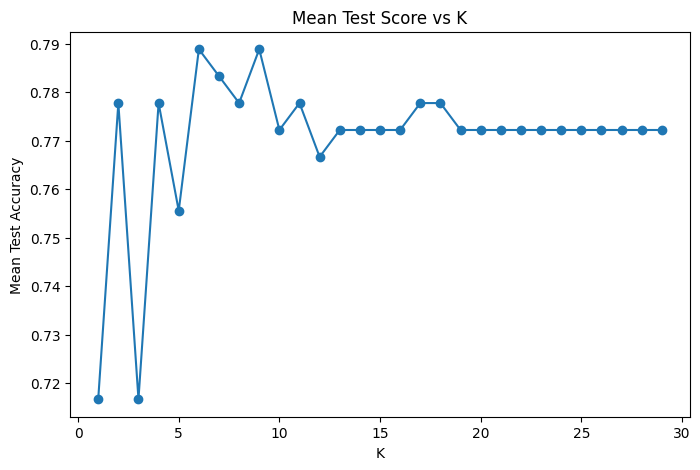

In [20]:
plt.figure(figsize=(8,5))
plt.plot(k_values, mean_scores, marker='o')

plt.xlabel("K")
plt.ylabel("Mean Test Accuracy")
plt.title("Mean Test Score vs K")
plt.show()

График показывает, что производительность модели варьируется в зависимости от разных значений k. Точность колеблется при малых значениях k и достигает самых высоких значений в районе от k=6 до k=9.
После этого производительность становится более стабильной, но немного ниже, что указывает на то, что большие значения k приводят к более обобщенным, но менее точным моделям.
В целом, k=6 обеспечивает хороший баланс между точностью и стабильностью.

### Финальная оценка модели

**ЗАДАНИЕ: используя объект grid classifier с предыдущего шага, создайте финальный отчёт "classification report" и матрицу "confusion matrix".**

In [21]:
# Напишите Ваш код здесь
from sklearn.metrics import classification_report, confusion_matrix

In [22]:
y_pred = grid.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.74      0.93      0.82        15
         1.0       0.00      0.00      0.00         5

    accuracy                           0.70        20
   macro avg       0.37      0.47      0.41        20
weighted avg       0.55      0.70      0.62        20



In [24]:
print(confusion_matrix(y_test, y_pred))

[[14  1]
 [ 5  0]]


Модель достигает точности 0,70 на тестовом наборе. Он хорошо работает для класса 0 с высокой запоминаемостью (0,93), правильно определяя большинство отрицательных случаев.
Однако модель не может предсказать класс 1 с нулевой точностью и полнотой. Это означает, что он не идентифицирует правильно ни одного положительного случая.
Такое поведение также отражается в матрице путаницы, где все положительные образцы классифицируются неправильно.

# Окончательный вывод

Модель KNN применялась с использованием конвейера с масштабированием и оптимизировалась с помощью поиска по сетке. Наилучшее значение k оказалось равным 6.
Хотя модель достигла разумной точности 0,70, более глубокий анализ показывает, что она не может правильно предсказать класс меньшинства. Модель хорошо работает с классом большинства, но полностью игнорирует класс меньшинства.
Это указывает на то, что одной только точности недостаточно для оценки модели. Дисбаланс классов в наборе данных существенно влияет на производительность, что приводит к плохому обобщению для класса 1.
В целом, хотя KNN обеспечивает простой и интерпретируемый подход, его производительность в этом наборе данных ограничена из-за высокой размерности и дисбаланса классов.